# **Práctica de Laboratorio Nro.004: Variables Aleatorias Discretas y Continuas**

###**Estudiante:** Julian Merino
###**Institución:** Universidad Nacional de Loja  
###**Asignatura:** Teoría de la Distribución y Probabilidad  
###**Fecha:** 02 de mayo de 2026
###**Ciclo:** Segundo Ciclo "A"


### 1. Introducción
En esta práctica se explora la naturaleza del azar mediante la modelación computacional. Utilizaremos el ecosistema de ciencia de datos de Python para diferenciar empíricamente entre variables discretas (lanzamiento de dados) y continuas (tiempos de respuesta de servidores).

###` 2. Objetivos de Aprendizaje
* Diferenciar entre variables aleatorias discretas y continuas.
* Interpretar y construir funciones de masa de probabilidad (PMF) y funciones de densidad (PDF).
* Calcular probabilidades acumuladas usando la función de distribución acumulada (CDF).

###Tarea 1: Configuracion del Entorno

1. Abra Jupyter Notebook o Google Colab.
2. Importe las librerias necesarias:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, norm, binom, uniform
import seaborn as sns

# Configuracion de estilo
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Entorno configurado correctamente")

Entorno configurado correctamente


###Tarea 2: Variable Aleatoria Discreta - Lanzamiento de Dado

**Caso:** X = resultado del lanzamiento de un dado justo

2. Defina la variable aleatoria y su PMF:


In [ ]:
# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6

# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])

# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))


Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999


3. Visualice la PMF:


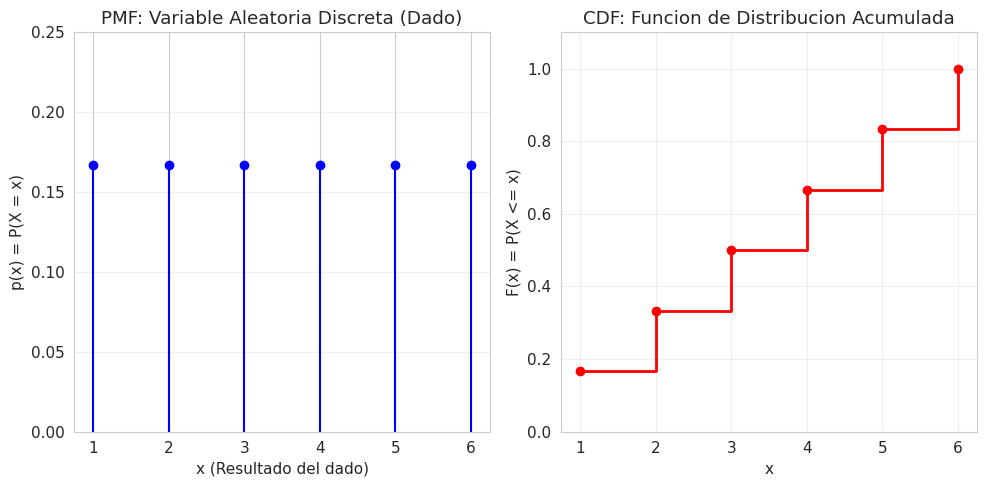

In [ ]:
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


4. Calcule probabilidades especificas:

In [ ]:
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")

# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")

# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")


P(X = 4) = 0.1667
P(X <= 3) = 0.5000
P(2 <= X <= 5) = 0.6667


###Tarea 3: Variable Aleatoria Continua - Distribucion Normal

**Caso:** X = tiempo de respuesta de un servidor (ms), distribuido normalmente
con mu = 200 y sigma = 30

5. Defina la distribucion y visualice la PDF:

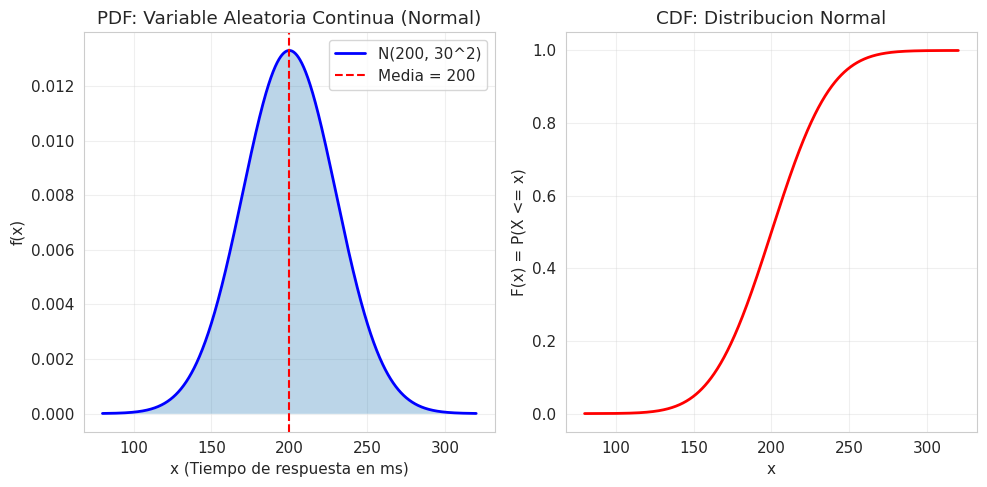

In [ ]:
# Parametros de la distribucion normal
mu = 200 # media
sigma = 30 # desviacion estandar

# Crear la distribucion
dist_normal = norm(loc=mu, scale=sigma)

# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF
pdf_normal = dist_normal.pdf(x)

# Visualizacion
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


6. Calcule probabilidades:

In [ ]:
# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")

# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")

# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")

P(X <= 180) = 0.2525 (25.25%)
P(X > 250) = 0.0478 (4.78%)
P(170 <= X <= 230) = 0.6827 (68.27%)

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms


###Tarea 4: Comparacion Visual PMF vs PDF

7. Cree una visualizacion comparativa:

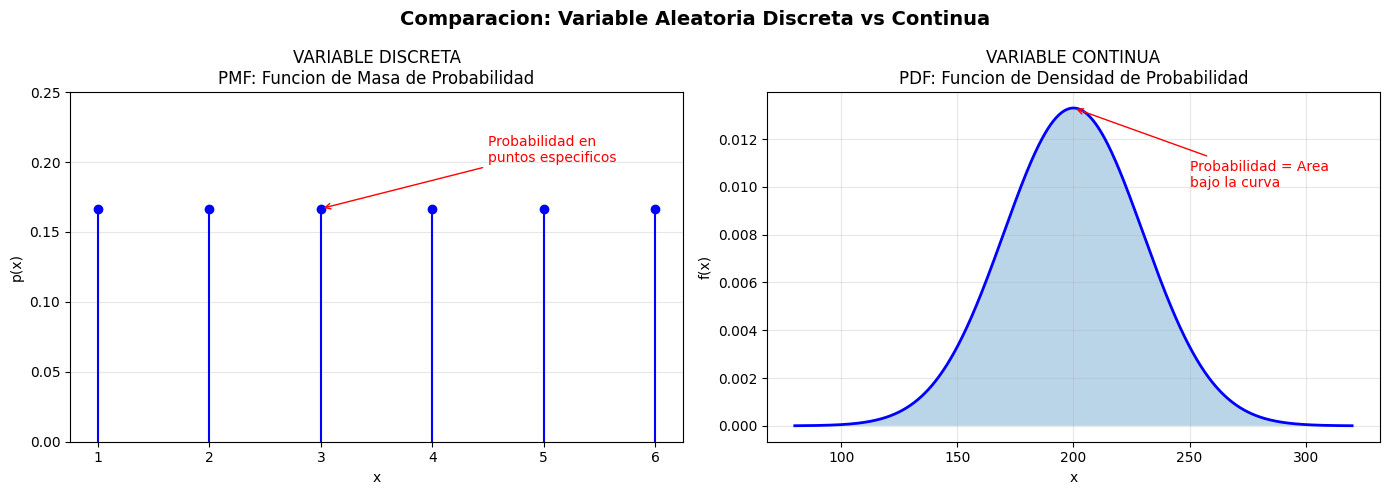

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- Variable Discreta (Dado) definitions (from previous cells) ---
x_valores = np.array([1, 2, 3, 4, 5, 6])
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

# --- Variable Continua (Normal) definitions (from previous cells) ---
mu = 200 # media
sigma = 30 # desviacion estandar
# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
# PDF
pdf_normal = norm.pdf(x, loc=mu, scale=sigma)


# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Variable Discreta (Dado)
axes[0].stem(x_valores, pmf_dado, basefmt="none", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)
# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6),
xytext=(4.5, 0.2),
arrowprops=dict(arrowstyle='->', color='red'),
fontsize=10, color='red')
# Variable Continua (Normal)
axes[1].plot(x, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x, pdf_normal, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(200, norm.pdf(200,
200, 30)), xytext=(250, 0.01),
arrowprops=dict(arrowstyle='->', color='red'),
fontsize=10, color='red')
plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua',
fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###Tarea 5: Aplicacion - Variables Aleatorias en la UNL

**Actividad grupal:** Identificar y clasificar variables aleatorias en el campus universitario.

8. En su grupo, identifique 5 variables aleatorias en diferentes areas de la UNL:

9. Para cada variable, determine:

* Tipo: Discreta / Continua
* Posibles valores que puede tomar
* Distribucion de probabilidad esperada (si se puede inferir)



---

* Biblioteca: _________________________________________________
* Cafeteria: _________________________________________________
* Laboratorios: ______________________________________________
* Estacionamiento: ___________________________________________
* Aulas de clase: ____________________________________________

In [ ]:
import pandas as pd

# 1. Configuración para separar y organizar las columnas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
# Removed pd.set_option('display.unicode.east_asian_width', True) as it can cause misalignment

# 2. Plantilla con encabezados en MAYÚSCULAS
variables_unl = [
    {
        'NOMBRE': 'Libros prestados por día',
        'UBICACION': 'Biblioteca Central',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0, 1, 2, ..., 200',
        'DISTRIBUCION ESPERADA': 'Poisson'
    },
    {
        'NOMBRE': 'Gasto promedio por estudiante',
        'UBICACION': 'Cafetería Central',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '$0.50 a $15.00',
        'DISTRIBUCION ESPERADA': 'Normal'
    },
    {
        'NOMBRE': 'Uso de maquinas por hora',
        'UBICACION': 'Lab. Computación',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0 a 10 maquinas',
        'DISTRIBUCION ESPERADA': 'Geométrica'
    },
    {
        'NOMBRE': 'Ocupación de estacionamiento (%)',
        'UBICACION': 'Estacionamiento UNL',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '0% a 100%',
        'DISTRIBUCION ESPERADA': 'Uniforme'
    },
    {
        'NOMBRE': 'Calificación final en Estadística',
        'UBICACION': 'Aulas de clase',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '0 a 10',
        'DISTRIBUCION ESPERADA': 'Beta'
    }
]

df = pd.DataFrame(variables_unl)

display(df)

,NOMBRE,UBICACION,TIPO,VALORES POSIBLES,DISTRIBUCION ESPERADA
0,Libros prestados por día,Biblioteca Central,Discreta,"0, 1, 2, ..., 200",Poisson
1,Gasto promedio por estudiante,Cafetería Central,Continua,$0.50 a $15.00,Normal
2,Uso de maquinas por hora,Lab. Computación,Discreta,0 a 10 maquinas,Geométrica
3,Ocupación de estacionamiento (%),Estacionamiento UNL,Continua,0% a 100%,Uniforme
4,Calificación final en Estadística,Aulas de clase,Continua,0 a 10,Beta


##FASE 3: DESPUES DE LA CLASE (Trabajo Autonomo - 60 min)

Fecha de entrega: Miercoles 30 de abril de 2026 (23:59)

11. Modifique el codigo de la Tarea 3 para representar una variable de su
eleccion:



* Opcion A: Distribución Bernoulli (lanzamiento de moneda)
* Opcion B: Distribución Uniforme discreta
* Opcion C: Distribución Binomial
* Genere las gráficas PMF/PDF y CDF para su distribución seleccionada.
* Calcule al menos 3 probabilidades especificas e interprete los resultados.
* Entregue un archivo. ipynb con:
* Código funcional y comentado
* Visualizaciones claras
* Interpretación de resultados

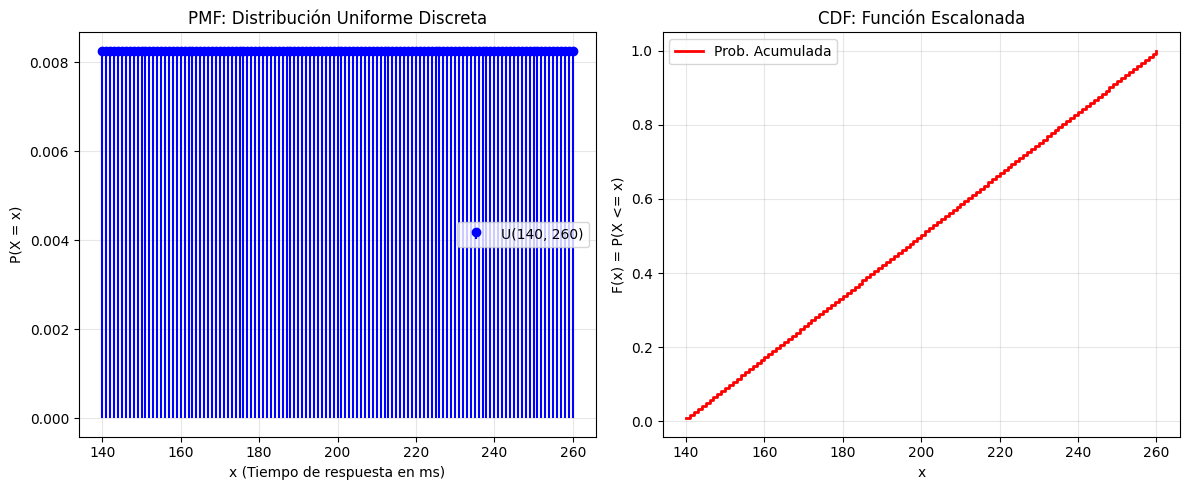

--- Resultados para Uniforme Discreta [140, 260] ---
a) P(X <= 180) = 0.3388 (33.88%)
b) P(X > 250) = 0.0826 (8.26%)
c) P(170 <= X <= 230) = 0.5041 (50.41%)
d) Percentil 95: 254 ms


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint

# 1. Definir los parámetros de la distribución Uniforme Discreta
# Definimos un rango de tiempo de respuesta entre 140ms y 260ms
bajo = 140
alto = 260

# Crear la distribución (randint en scipy es uniforme discreta)
# Nota: 'high' es exclusivo, por lo que sumamos 1 para incluir el límite superior
dist_uniforme = randint(low=bajo, high=alto + 1)

# Rango de valores (solo números enteros)
x = np.arange(bajo, alto + 1)

# 2. PMF (Función de Masa de Probabilidad) y CDF
pmf_uniforme = dist_uniforme.pmf(x)
cdf_uniforme = dist_uniforme.cdf(x)

# 3. Visualización
plt.figure(figsize=(12, 5))

# Gráfica PMF: Representamos puntos aislados
# (Probabilidad Exacta de que ocurra un evento especifico)
plt.subplot(1, 2, 1)
plt.stem(x, pmf_uniforme, linefmt='b-', markerfmt='bo', basefmt=' ', label=f'U({bajo}, {alto})')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('P(X = x)')
plt.title('PMF: Distribución Uniforme Discreta')
plt.legend()
plt.grid(alpha=0.3)

# Gráfica CDF: Representamos una función escalonada
# (Acumulacion de todas las probabilidades desde el inicio hasta llegar a un valor especifico)
plt.subplot(1, 2, 2)
plt.step(x, cdf_uniforme, where='post', color='red', linewidth=2, label='Prob. Acumulada')
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Función Escalonada')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Cálculos de Probabilidad
# Calculo de 3 probabilidades especificas, interpretación de resultados.
print(f"--- Resultados para Uniforme Discreta [{bajo}, {alto}] ---")

# a) P(X <= 180)
prob_menor_180 = dist_uniforme.cdf(180)
print(f"a) P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")
# La probabilidad de que el servidor responda en 180 ms o menos

# b) P(X > 250)
prob_mayor_250 = 1 - dist_uniforme.cdf(250)
print(f"b) P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")
# Tiempos de respuesta mayores a 250 ms

# c) P(170 <= X <= 230)
prob_entre = dist_uniforme.cdf(230) - dist_uniforme.cdf(169)
print(f"c) P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")
# La probabilidad de que la respuesta esté entre 170 y 230 ms

# d) Percentil 95
# Encontrar los datos sin encontrar en base a la probabilidad.
p95 = dist_uniforme.ppf(0.95)
print(f"d) Percentil 95: {p95:.0f} ms")

##Preguntas de control

* ¿Cual es la diferencia fundamental entre una variable aleatoria discreta y
una continua?

**Discretas:** Toman valores separados o "saltos" finitos o infinitos, solo numeros enteros. Como las cosas que puedes contar con los dedos: cantidad de computadoras, cantidad de personas. cantidad de autos, etc. Puedes tener 1, 2 o 3, pero no puedes tener 1.5 personas, ni 2,5 autos.

**Continuas:** Pueden tomar cualquier valor dentro de un rango, incluyendo todos los decimales imaginables. Como las cosas que mides con un instrumento (un cronómetro, una balanza): tiempo, peso, voltaje, distancia. Entre 1 segundo y 2 segundos, hay infinitas fracciones (1.51s, 1.578s, 1.5873s...).



* Por qué en una variable continua P(X = x) = 0 para cualquier valor especifico
x?

Como en una variable continua hay infinitos valores posibles, la probabilidad de seleccionar un solo número exacto y perfecto es 1 dividido para infinito. Y 1 entre infinito es 0. Por eso, en variables continuas nunca calculamos la probabilidad de un punto exacto, sino la probabilidad de que el valor caiga dentro de un "rango" (por ejemplo, que la manzana pese entre 149 y 151 gramos).


* Explique la relacion entre la PMF/PDF y la CDF. ¿Como se obtiene una de
la otra?

Función de Masa (para discretas) y Función de Densidad (para continuas): Describen el comportamiento probabilístico local. Asignan un peso o una densidad de probabilidad a eventos aislados o agrupaciones infinitesimales dentro del espacio muestral.

Función de Distribución Acumulada: Describe el comportamiento global creciente de la variable. Cuantifica la probabilidad total consolidada desde el límite inferior absoluto del dominio hasta un límite superior especificado. Va sumando todas las probabilidades anteriores.


* Una variable aleatoria X representa el número de estudiantes que llegan
tarde a clase. ¿Es X discreta o continua? Justifique.

La variable es Discreta

Ya que a los estudiantes los tienes que contar en números enteros. Pueden llegar tarde 0, 3, 5 o 20 estudiantes, pero es imposible que MEDIO estudiante llegue tarde.

* Calcule P(X = 5) para una variable continua con PDF f(x) = 2x en [0,1].
Explique su respuesta.

El problema te dice que esta variable solo existe en el intervalo del [0 al 1]. El número 5 está fuera de ese rango por lo que es imposible que ocurra.

* Dibuje aproximadamente la CDF de una variable discreta que toma valores
{1, 2, 3} con probabilidades {0.3, 0.5, 0.2}.

-VALOR 1: La probabilidad acumulada es inexistente (0.0).

-En el valor 1: La función experimenta un salto equivalente a su primera masa de probabilidad, alcanzando el nivel de 0.3. Este nivel se mantiene constante hasta llegar al siguiente punto.

-En el valor 2: Se adiciona la probabilidad correspondiente a este estado (0.5). El nuevo nivel acumulado llego a 0.8 (0.3 + 0.5).

-En el valor 3: Se integra la última probabilidad (0.2). La función alcanza la unidad total, es decir, el 1.0 (resultado de 0.8 + 0.2). A partir de este punto, la gráfica se mantiene como una línea recta horizontal constante hacia el infinito, confirmando que el espacio muestral se ha cubierto en su totalidad.

* Identifique una variable aleatoria continua en el contexto de la carrera de
Computación y justifique porque es continua

**Variable propuesta:** El nivel exacto de voltaje eléctrico suministrado por un panel solar a un circuito.

El voltaje (o tensión eléctrica) es una magnitud física fundamental que se mide con instrumentos, no es algo que se pueda contabilizar por unidades indivisibles.

Si tienes un panel solar recargando una batería y la tensión sube de 3.7 a 4.2 voltios a medida que le da el sol, el nivel de energía no pasa de un número a otro. Obligatoriamente tiene que adquirir grandes decimales intermedios (por ejemplo, 3.8945, etc voltios).

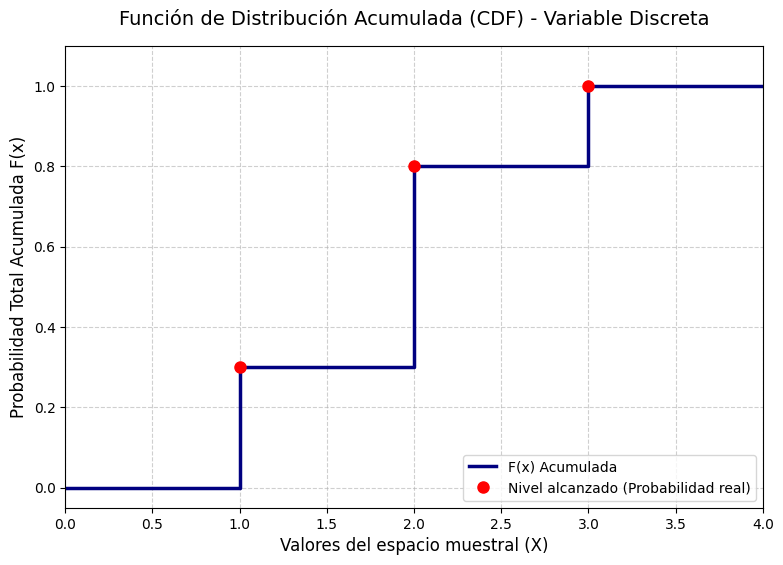

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definición del espacio muestral y la función de masa de probabilidad (PMF)
valores_x = [1, 2, 3]
probabilidades = [0.3, 0.5, 0.2]

# 2. Cálculo de la Función de Distribución Acumulada (CDF)
# La función cumsum realiza la suma acumulativa de los elementos del arreglo
cdf_acumulada = np.cumsum(probabilidades)

# 3. Preparación de los vectores para forzar el dibujo escalonado
# Se añaden límites inferiores y superiores artificiales (0 y 4)
x_grafica = [0, 1, 2, 3, 4]
y_grafica = [0, 0.3, 0.8, 1.0, 1.0]

# 4. Configuración del entorno gráfico
plt.figure(figsize=(9, 6))

# Trazado de la función escalonada.
plt.step(x_grafica, y_grafica, where='post', color='navy', linewidth=2.5, label='F(x) Acumulada')

# Añadir marcadores para visualizar los puntos exactos de evaluación
plt.plot(valores_x, cdf_acumulada, 'ro', markersize=8, label='Nivel alcanzado (Probabilidad real)')

# Configuraciones estéticas
plt.title('Función de Distribución Acumulada (CDF) - Variable Discreta', fontsize=14, pad=15)
plt.xlabel('Valores del espacio muestral (X)', fontsize=12)
plt.ylabel('Probabilidad Total Acumulada F(x)', fontsize=12)

# Delimitación de los ejes para una visualización
plt.xlim(0, 4)
plt.ylim(-0.05, 1.1)

# Cuadrícula
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right')

plt.show()

## Conclusiones

* Comprender si la información que manejamos se basa en conteos exactos (cosas que se pueden numerar) o en mediciones (cosas que fluyen y tienen decimales) es el primer paso para cualquier análisis. Confundir estos dos tipos de información lleva a conclusiones erróneas.

* Observar eventos individuales o datos aislados ofrece una visión muy limitada. Para comprender realmente cómo funciona un sistema, un proceso o un fenómeno, siempre es mejor analizar cómo se acumulan y se comportan esos datos en conjunto.

## Recomendaciones

* Antes de tomar decisiones, programar algoritmos o aplicar cualquier modelo de análisis, tómate el tiempo de clasificar y entender correctamente qué tipo de información tienes

* Evita usar la misma solución o fórmula para todo. Selecciona siempre métodos que respeten los límites lógicos de tu problema (por ejemplo, si estás midiendo algo que lógicamente no puede pasar del 100%, asegúrate de usar un modelo que respete ese limite máximo).

## Bibliografia

[1] Walpole, R. E., et al. (2016). Probabilidad y estadistica para ingenieria y
ciencias (9na ed.). Cengage Learning.

[2] Video-tutorial: "PMF vs PDF: Como entiende Python el azar?" (Enlace en
EVA)

[3] Documentacion SciPy Stats.
https://docs.scipy.org/doc/scipy/reference/stats.html